In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import os 

In [73]:
GRAPH_LOG_DIR = 'logs/paper_graph_logs'

dfs = {}
for file in os.listdir(GRAPH_LOG_DIR):
    if file.endswith('_iterations.csv'):
        name = file.replace('_iterations.csv', '')
        dfs[name] = pd.read_csv(os.path.join(GRAPH_LOG_DIR, file))

print(f'Loaded {len(dfs)} iteration logs from {GRAPH_LOG_DIR}')

Loaded 9 iteration logs from logs/paper_graph_logs


In [74]:
for name, df in dfs.items():
    print(df['break_op'].unique())

['geo' 'random' 'tool' 'vehicle']
['tool' 'geo' 'random' 'vehicle' 'worst_day']
['tool' 'geo' 'random' 'vehicle_days']
['tool' 'vehicle' 'geo' 'random' 'distance' 'worst_day']
['vehicle_days' 'geo' 'random' 'tool']
['distance' 'worst_day' 'geo' 'random']
['tool' 'random' 'geo']
['tool' 'geo' 'random' 'vehicle_days' 'distance' 'worst_day']
['geo' 'random' 'vehicle' 'tool' 'distance']


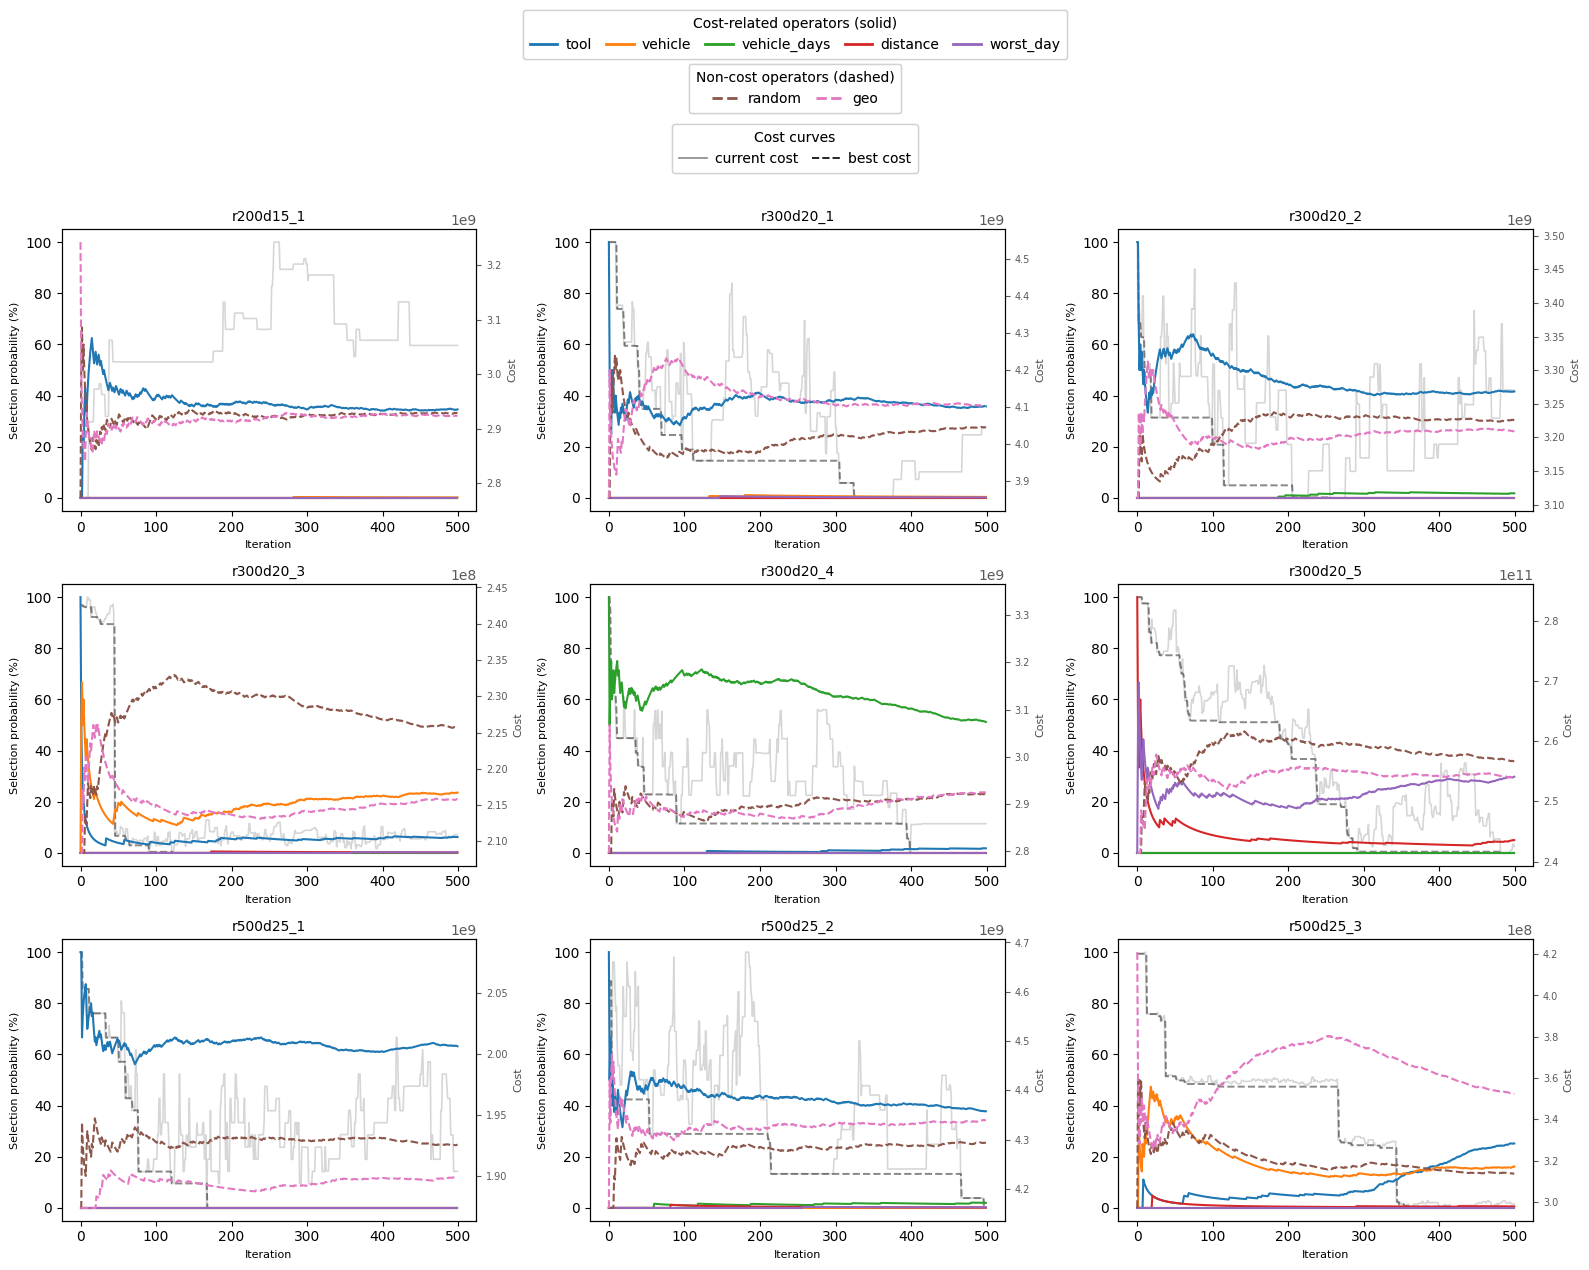

In [ ]:
names = sorted(dfs.keys())
cols = 3
rows = -(-len(names) // cols)

# worst_day is cost-guided: its selection weight uses breakdown['distance']
cost_related_ops = ['tool', 'vehicle', 'vehicle_days', 'distance', 'worst_day']
non_cost_ops = ['random', 'geo']

fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()

for i, name in enumerate(names):
    ax = axes[i]
    df = dfs[name]

    if 'iteration' not in df.columns or 'break_op' not in df.columns:
        ax.set_title(name.replace('challenge_', ''), fontsize=10)
        ax.text(0.5, 0.5, 'Missing iteration/break_op columns', ha='center', va='center')
        ax.set_axis_off()
        continue


    for op in cost_related_ops + non_cost_ops:
        prob = df['break_op'].eq(op).expanding().mean() * 100.0
        line_style = '-' if op in cost_related_ops else '--'
        ax.plot(df['iteration'], prob, linestyle=line_style)

    ax2 = ax.twinx()
    if 'current_cost' in df.columns:
        ax2.plot(df['iteration'], df['current_cost'], color='0.55', alpha=0.35, linewidth=1.2, linestyle='-')
    if 'best_cost' in df.columns:
        ax2.plot(df['iteration'], df['best_cost'], color='0.15', alpha=0.55, linewidth=1.4, linestyle='--')

    # Keep selection curves visually in front, cost lines in the background
    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)

    ax.set_title(name.replace('challenge_', ''), fontsize=10)
    ax.set_xlabel('Iteration', fontsize=8)
    ax.set_ylabel('Selection probability (%)', fontsize=8)
    ax2.set_ylabel('Cost', fontsize=8, color='0.3')
    ax2.tick_params(axis='y', labelsize=7, colors='0.35')

for i in range(len(names), len(axes)):
    axes[i].set_visible(False)

from matplotlib.lines import Line2D


cost_related_handles = [
    Line2D([0], [0], color='tab:blue',   lw=2, linestyle='-', label='tool'),
    Line2D([0], [0], color='tab:orange', lw=2, linestyle='-', label='vehicle'),
    Line2D([0], [0], color='tab:green',  lw=2, linestyle='-', label='vehicle_days'),
    Line2D([0], [0], color='tab:red',    lw=2, linestyle='-', label='distance'),
    Line2D([0], [0], color='tab:purple', lw=2, linestyle='-', label='worst_day'),
]

non_cost_handles = [
    Line2D([0], [0], color='tab:brown', lw=2, linestyle='--', label='random'),
    Line2D([0], [0], color='tab:pink',  lw=2, linestyle='--', label='geo'),
]

cost_curve_handles = [
    Line2D([0], [0], color='0.55', lw=1.2, linestyle='-',  label='current cost'),
    Line2D([0], [0], color='0.15', lw=1.4, linestyle='--', label='best cost'),
]

legend1 = fig.legend(
    handles=cost_related_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.06),
    ncol=5,
    fontsize=10,
    frameon=True,
    borderpad=0.5,
    columnspacing=1.0,
    handlelength=2.0,
    handletextpad=0.6,
    fancybox=True,
    shadow=False,
    title='Cost-related operators (solid)',
    title_fontsize=10,
 )

legend2 = fig.legend(
    handles=non_cost_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.015),
    ncol=2,
    fontsize=10,
    frameon=True,
    borderpad=0.5,
    columnspacing=1.0,
    handlelength=2.0,
    handletextpad=0.6,
    fancybox=True,
    shadow=False,
    title='Non-cost operators (dashed)',
    title_fontsize=10,
 )

legend3 = fig.legend(
    handles=cost_curve_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.965),
    ncol=2,
    fontsize=10,
    frameon=True,
    borderpad=0.5,
    columnspacing=1.0,
    handlelength=2.0,
    handletextpad=0.6,
    fancybox=True,
    shadow=False,
    title='Cost curves',
    title_fontsize=10,
 )

fig.add_artist(legend1)
fig.add_artist(legend2)
fig.add_artist(legend3)

fig.savefig('operator_selection_probability_cost_curves.png', dpi=300, bbox_inches='tight')
plt.tight_layout(rect=[0, 0, 1, 0.90])

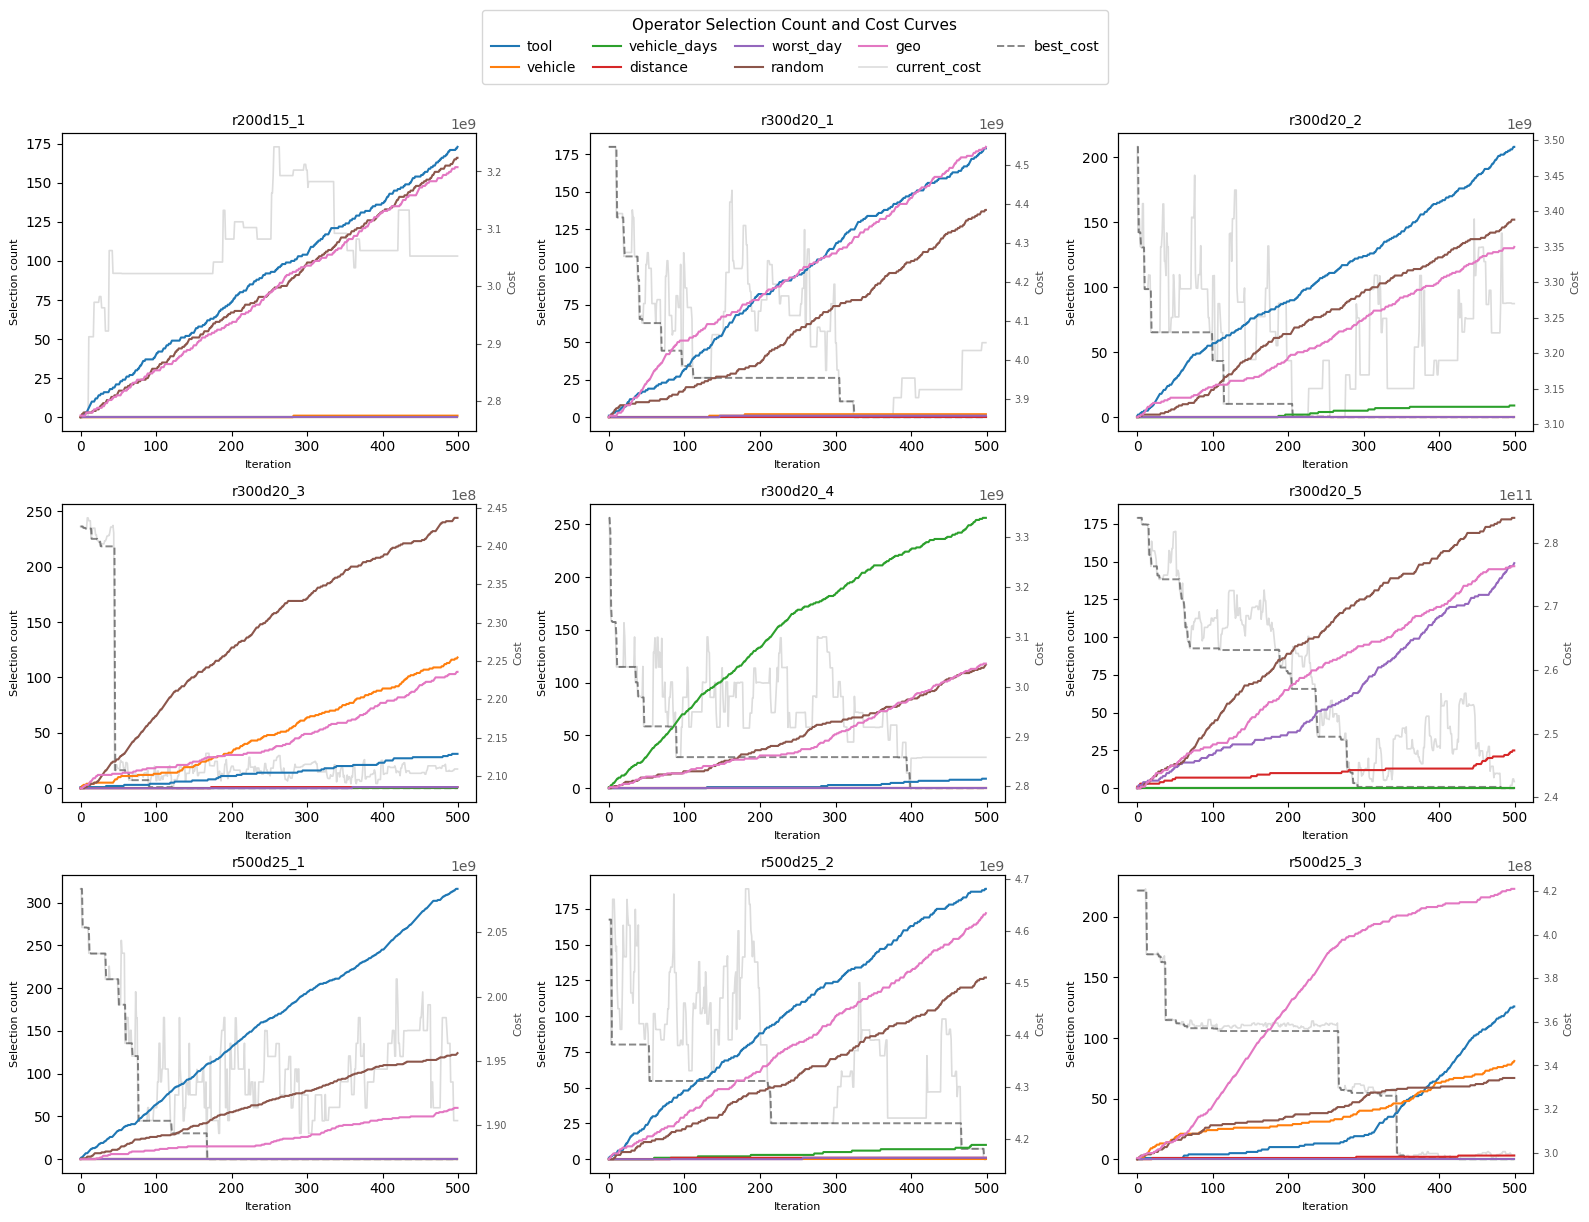

In [76]:
# Selection count + cost curves
names = sorted(dfs.keys())
cols = 3
rows = -(-len(names) // cols)

all_ops = ['tool', 'vehicle', 'vehicle_days', 'distance', 'worst_day', 'random', 'geo']

fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()

legend_h1, legend_l1 = [], []
legend_h2, legend_l2 = [], []

for i, name in enumerate(names):
    ax = axes[i]
    df = dfs[name].copy()

    if 'iteration' not in df.columns or 'break_op' not in df.columns:
        ax.set_title(name.replace('challenge_', ''), fontsize=10)
        ax.text(0.5, 0.5, 'Missing iteration/break_op columns', ha='center', va='center')
        ax.set_axis_off()
        continue

    # Cumulative selection count for each operator.
    for op in all_ops:
        count = df['break_op'].eq(op).cumsum()
        ax.plot(df['iteration'], count, label=op)

    ax2 = ax.twinx()
    if 'current_cost' in df.columns:
        ax2.plot(df['iteration'], df['current_cost'], color='0.55', alpha=0.30, linewidth=1.2, label='current_cost')
    if 'best_cost' in df.columns:
        ax2.plot(df['iteration'], df['best_cost'], color='0.15', alpha=0.55, linewidth=1.4, linestyle='--', label='best_cost')

    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)

    ax.set_title(name.replace('challenge_', ''), fontsize=10)
    ax.set_xlabel('Iteration', fontsize=8)
    ax.set_ylabel('Selection count', fontsize=8)
    ax2.set_ylabel('Cost', fontsize=8, color='0.3')
    ax2.tick_params(axis='y', labelsize=7, colors='0.35')

    if i == 0:
        legend_h1, legend_l1 = ax.get_legend_handles_labels()
        legend_h2, legend_l2 = ax2.get_legend_handles_labels()

for i in range(len(names), len(axes)):
    axes[i].set_visible(False)

fig.legend(
    legend_h1 + legend_h2,
    legend_l1 + legend_l2,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=5,
    fontsize=10,
    frameon=True,
    borderpad=0.6,
    columnspacing=1.2,
    handlelength=2.0,
    handletextpad=0.6,
    fancybox=True,
    shadow=False,
    title='Operator Selection Count and Cost Curves',
    title_fontsize=11,
 )

fig.savefig('operator_selection_count_cost_curves.png', dpi=300, bbox_inches='tight')
plt.tight_layout(rect=[0, 0, 1, 0.94])

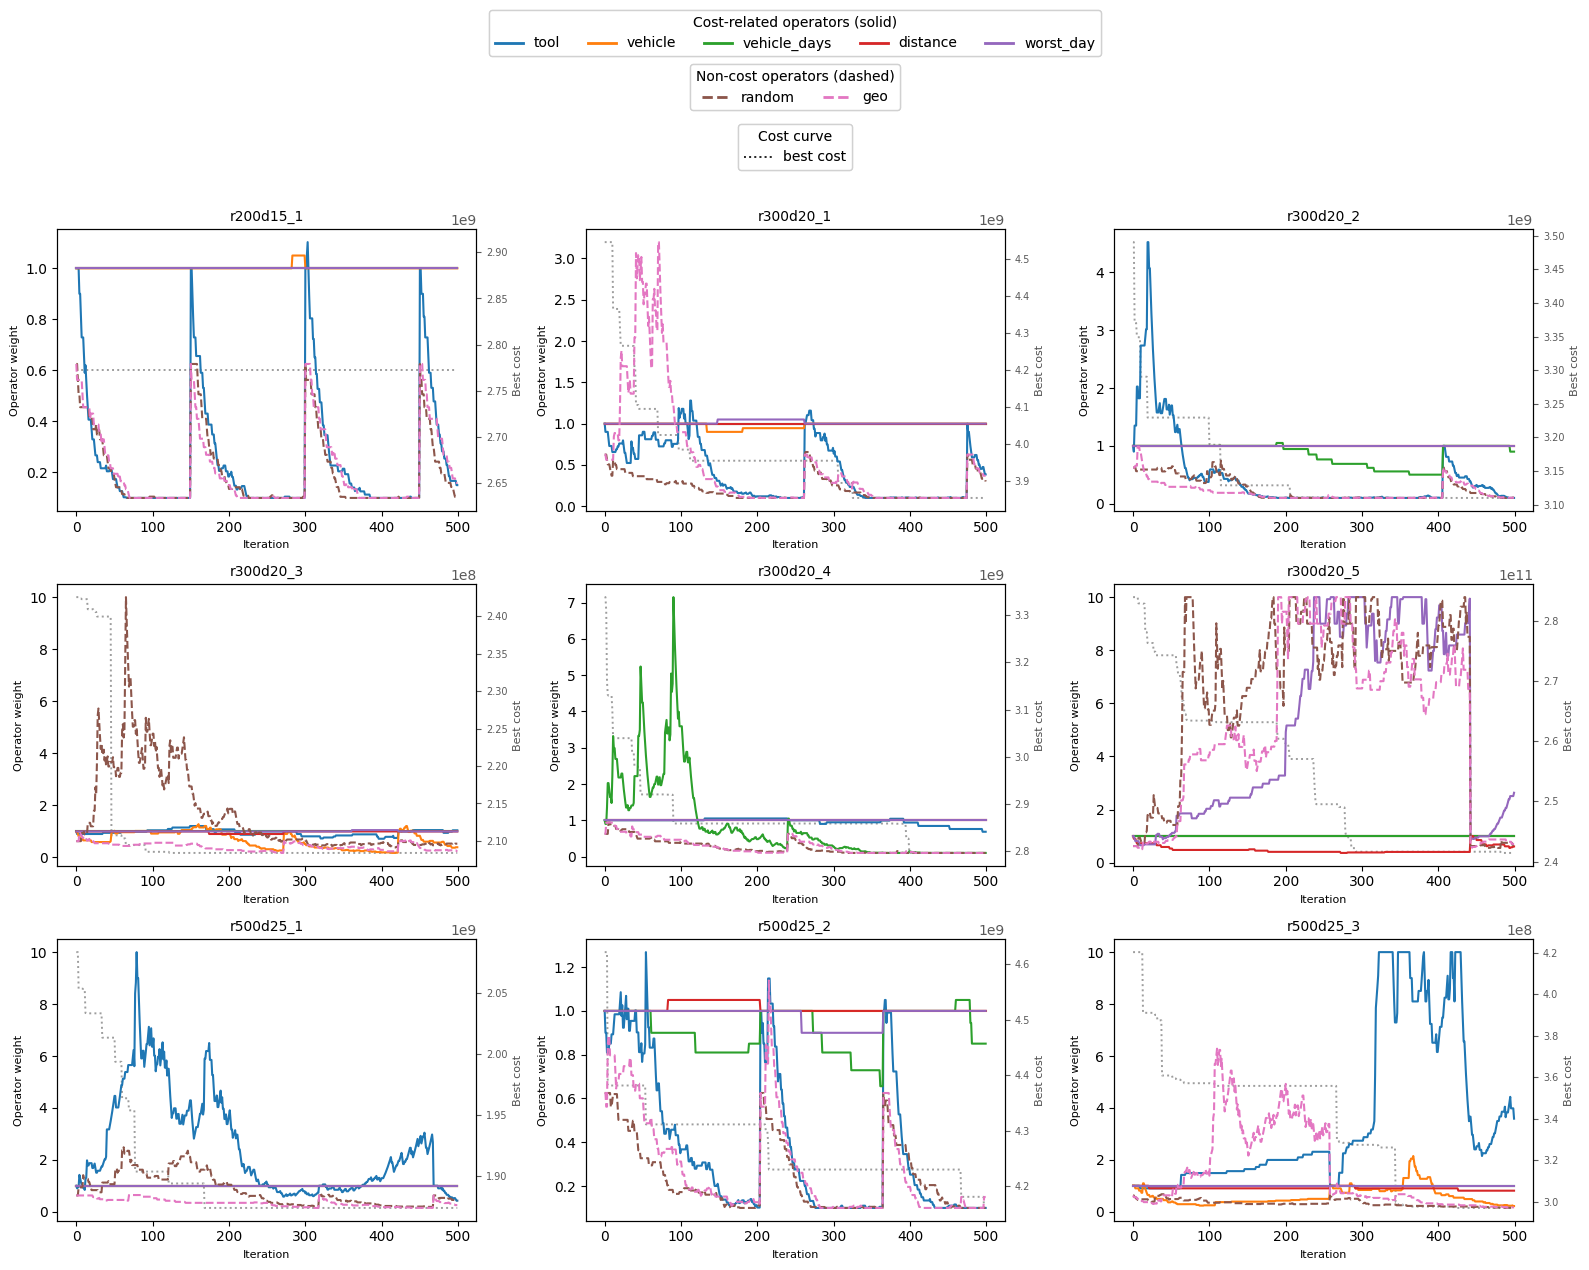

In [77]:
# Operator weight development over iterations
names = sorted(dfs.keys())
cols = 3
rows = -(-len(names) // cols)

cost_related_ops = ['tool', 'vehicle', 'vehicle_days', 'distance', 'worst_day']
non_cost_ops      = ['random', 'geo']
wb_map = {
    'tool':         'wb_tool',
    'vehicle':      'wb_vehicle',
    'vehicle_days': 'wb_veh_days',
    'distance':     'wb_distance',
    'worst_day':    'wb_worst',
    'random':       'wb_random',
    'geo':          'wb_geo',
}

fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()

for i, name in enumerate(names):
    ax = axes[i]
    df = dfs[name]

    missing = [c for c in wb_map.values() if c not in df.columns]
    if 'iteration' not in df.columns or missing:
        ax.set_title(name.replace('challenge_', ''), fontsize=10)
        ax.text(0.5, 0.5, f'Missing columns: {missing}', ha='center', va='center', fontsize=7)
        ax.set_axis_off()
        continue

    for op in cost_related_ops + non_cost_ops:
        ls = '-' if op in cost_related_ops else '--'
        ax.plot(df['iteration'], df[wb_map[op]], linestyle=ls, label=op)

    ax2 = ax.twinx()
    if 'best_cost' in df.columns:
        ax2.plot(df['iteration'], df['best_cost'], color='0.15', alpha=0.45,
                 linewidth=1.4, linestyle=':', label='best cost')

    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)
    ax.set_title(name.replace('challenge_', ''), fontsize=10)
    ax.set_xlabel('Iteration', fontsize=8)
    ax.set_ylabel('Operator weight', fontsize=8)
    ax2.set_ylabel('Best cost', fontsize=8, color='0.3')
    ax2.tick_params(axis='y', labelsize=7, colors='0.35')

for i in range(len(names), len(axes)):
    axes[i].set_visible(False)

from matplotlib.lines import Line2D

cost_wt_handles = [
    Line2D([0],[0], color='tab:blue',   lw=2, linestyle='-',  label='tool'),
    Line2D([0],[0], color='tab:orange', lw=2, linestyle='-',  label='vehicle'),
    Line2D([0],[0], color='tab:green',  lw=2, linestyle='-',  label='vehicle_days'),
    Line2D([0],[0], color='tab:red',    lw=2, linestyle='-',  label='distance'),
    Line2D([0],[0], color='tab:purple', lw=2, linestyle='-',  label='worst_day'),
]
non_cost_wt_handles = [
    Line2D([0],[0], color='tab:brown', lw=2, linestyle='--', label='random'),
    Line2D([0],[0], color='tab:pink',  lw=2, linestyle='--', label='geo'),
]
cost_curve_wt_handle = [
    Line2D([0],[0], color='0.15', lw=1.4, linestyle=':', label='best cost'),
]

lg1 = fig.legend(handles=cost_wt_handles, loc='upper center',
                 bbox_to_anchor=(0.5, 1.06), ncol=5, fontsize=10,
                 frameon=True, fancybox=True,
                 title='Cost-related operators (solid)', title_fontsize=10)
lg2 = fig.legend(handles=non_cost_wt_handles, loc='upper center',
                 bbox_to_anchor=(0.5, 1.015), ncol=2, fontsize=10,
                 frameon=True, fancybox=True,
                 title='Non-cost operators (dashed)', title_fontsize=10)
lg3 = fig.legend(handles=cost_curve_wt_handle, loc='upper center',
                 bbox_to_anchor=(0.5, 0.965), ncol=1, fontsize=10,
                 frameon=True, fancybox=True,
                 title='Cost curve', title_fontsize=10)
fig.add_artist(lg1)
fig.add_artist(lg2)
fig.add_artist(lg3)

fig.savefig('operator_weight_development.png', dpi=300, bbox_inches='tight')
plt.tight_layout(rect=[0, 0, 1, 0.90])

In [ ]:
from pathlib import Path
import pandas as pd

logs_root = Path("logs")
csv_paths = sorted(logs_root.rglob("*_iterations.csv"))

records = []
missing_best_cost = []
read_errors = {}

for csv_path in csv_paths:
    stem = csv_path.stem
    challenge = stem[: -len("_iterations")] if stem.endswith("_iterations") else stem

    try:
        df = pd.read_csv(csv_path)
    except Exception as exc:
        read_errors[str(csv_path)] = str(exc)
        continue

    if "best_cost" not in df.columns:
        missing_best_cost.append(str(csv_path))
        continue

    series = pd.to_numeric(df["best_cost"], errors="coerce").dropna()
    if series.empty:
        continue

    records.append(
        {
            "challenge": challenge,
            "last_best_cost": series.iloc[-1],
            "file": str(csv_path),
            "is_paper_graph_logs": "paper_graph_logs" in str(csv_path),
            "path_depth": len(csv_path.parts),
        }
    )

long_df = pd.DataFrame(records)

if not long_df.empty:

    comparison_df = (
        long_df.sort_values(["challenge", "is_paper_graph_logs", "path_depth", "file"])
.drop_duplicates(subset=["challenge"], keep="first")
        .loc[:, ["challenge", "last_best_cost"]]
        .sort_values("challenge")
        .reset_index(drop=True)
    )
else:
    comparison_df = pd.DataFrame(columns=["challenge", "last_best_cost"])

print(f"CSV files found: {len(csv_paths)}")
print(f"Files parsed with best_cost: {len(long_df)}")
print(f"Unique challenges: {comparison_df['challenge'].nunique() if not comparison_df.empty else 0}")
print(f"Files missing best_cost: {len(missing_best_cost)}")
print(f"Files with read errors: {len(read_errors)}")

if comparison_df.empty:
    print("No best_cost values found.")
else:
    display(comparison_df)



CSV files found: 17
Files parsed with best_cost: 17
Unique challenges: 9
Files missing best_cost: 0
Files with read errors: 0


,challenge,last_best_cost
0,challenge_r200d15_1,2772438244
1,challenge_r300d20_1,3854107712
2,challenge_r300d20_2,3109798023
3,challenge_r300d20_3,208394368
4,challenge_r300d20_4,2796410810
5,challenge_r300d20_5,241446680005
6,challenge_r500d25_1,1873566814
7,challenge_r500d25_2,4161058651
8,challenge_r500d25_3,297033941


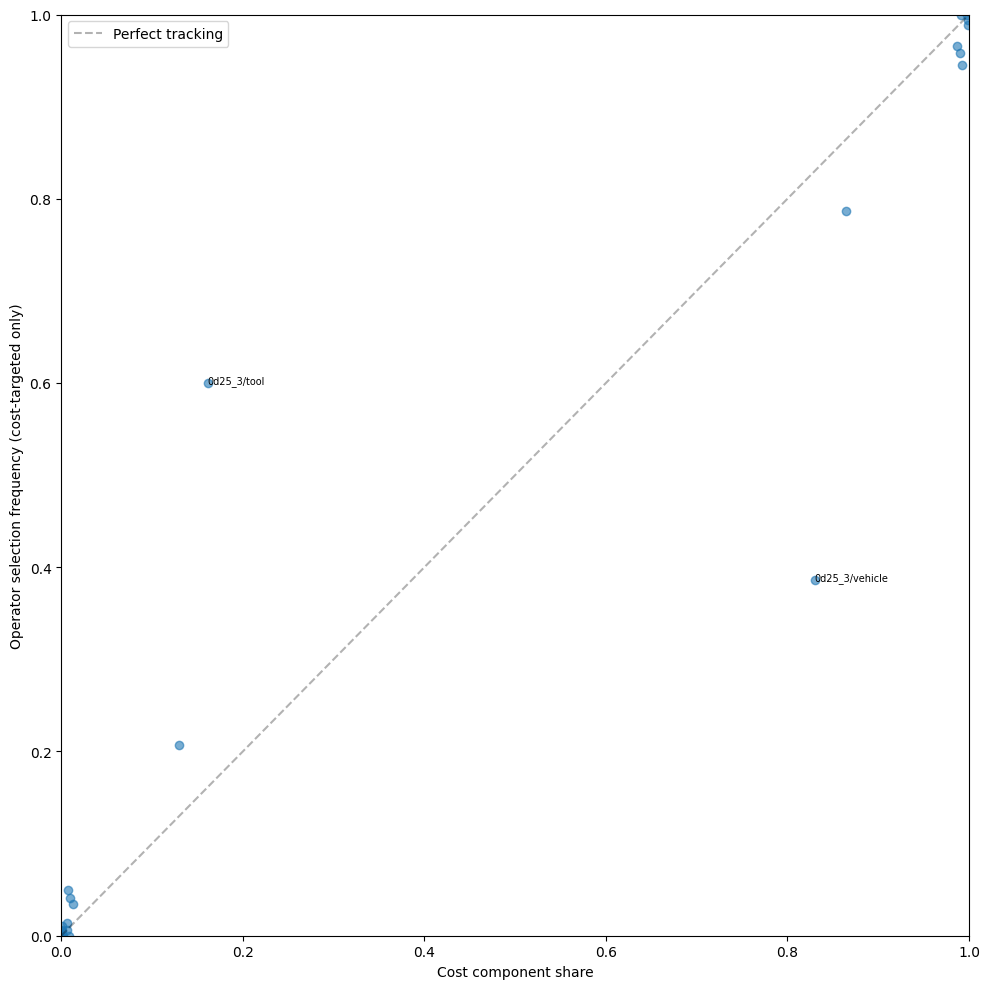

In [ ]:
cost_shares = []
selection_shares = []
labels = []

cost_ops = ['tool', 'vehicle', 'vehicle_days', 'distance']

for name, df in dfs.items():
    breakdown = [df['bd_tool'].mean(), df['bd_vehicle'].mean(), 
                 df['bd_veh_days'].mean(), df['bd_distance'].mean()]
    breakdown_pct = [b / sum(breakdown) for b in breakdown]
    
    cost_df = df[df['break_op'].isin(cost_ops)]
    counts = cost_df['break_op'].value_counts()
    total = counts.sum()
    sel = [counts.get(comp, 0) / total for comp in cost_ops]
    
    for comp, cs, ss in zip(cost_ops, breakdown_pct, sel):
        cost_shares.append(cs)
        selection_shares.append(ss)
        labels.append(f'{name[-6:]}/{comp}')

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(cost_shares, selection_shares, alpha=0.6)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect tracking')

for i, label in enumerate(labels):

    diff = abs(cost_shares[i] - selection_shares[i])
    if diff > 0.3:
        ax.annotate(label, (cost_shares[i], selection_shares[i]), fontsize=7)

ax.set_xlabel('Cost component share')
ax.set_ylabel('Operator selection frequency (cost-targeted only)')
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

fig.savefig('cost_share_vs_selection_frequency.png', dpi=300, bbox_inches='tight')
plt.tight_layout()

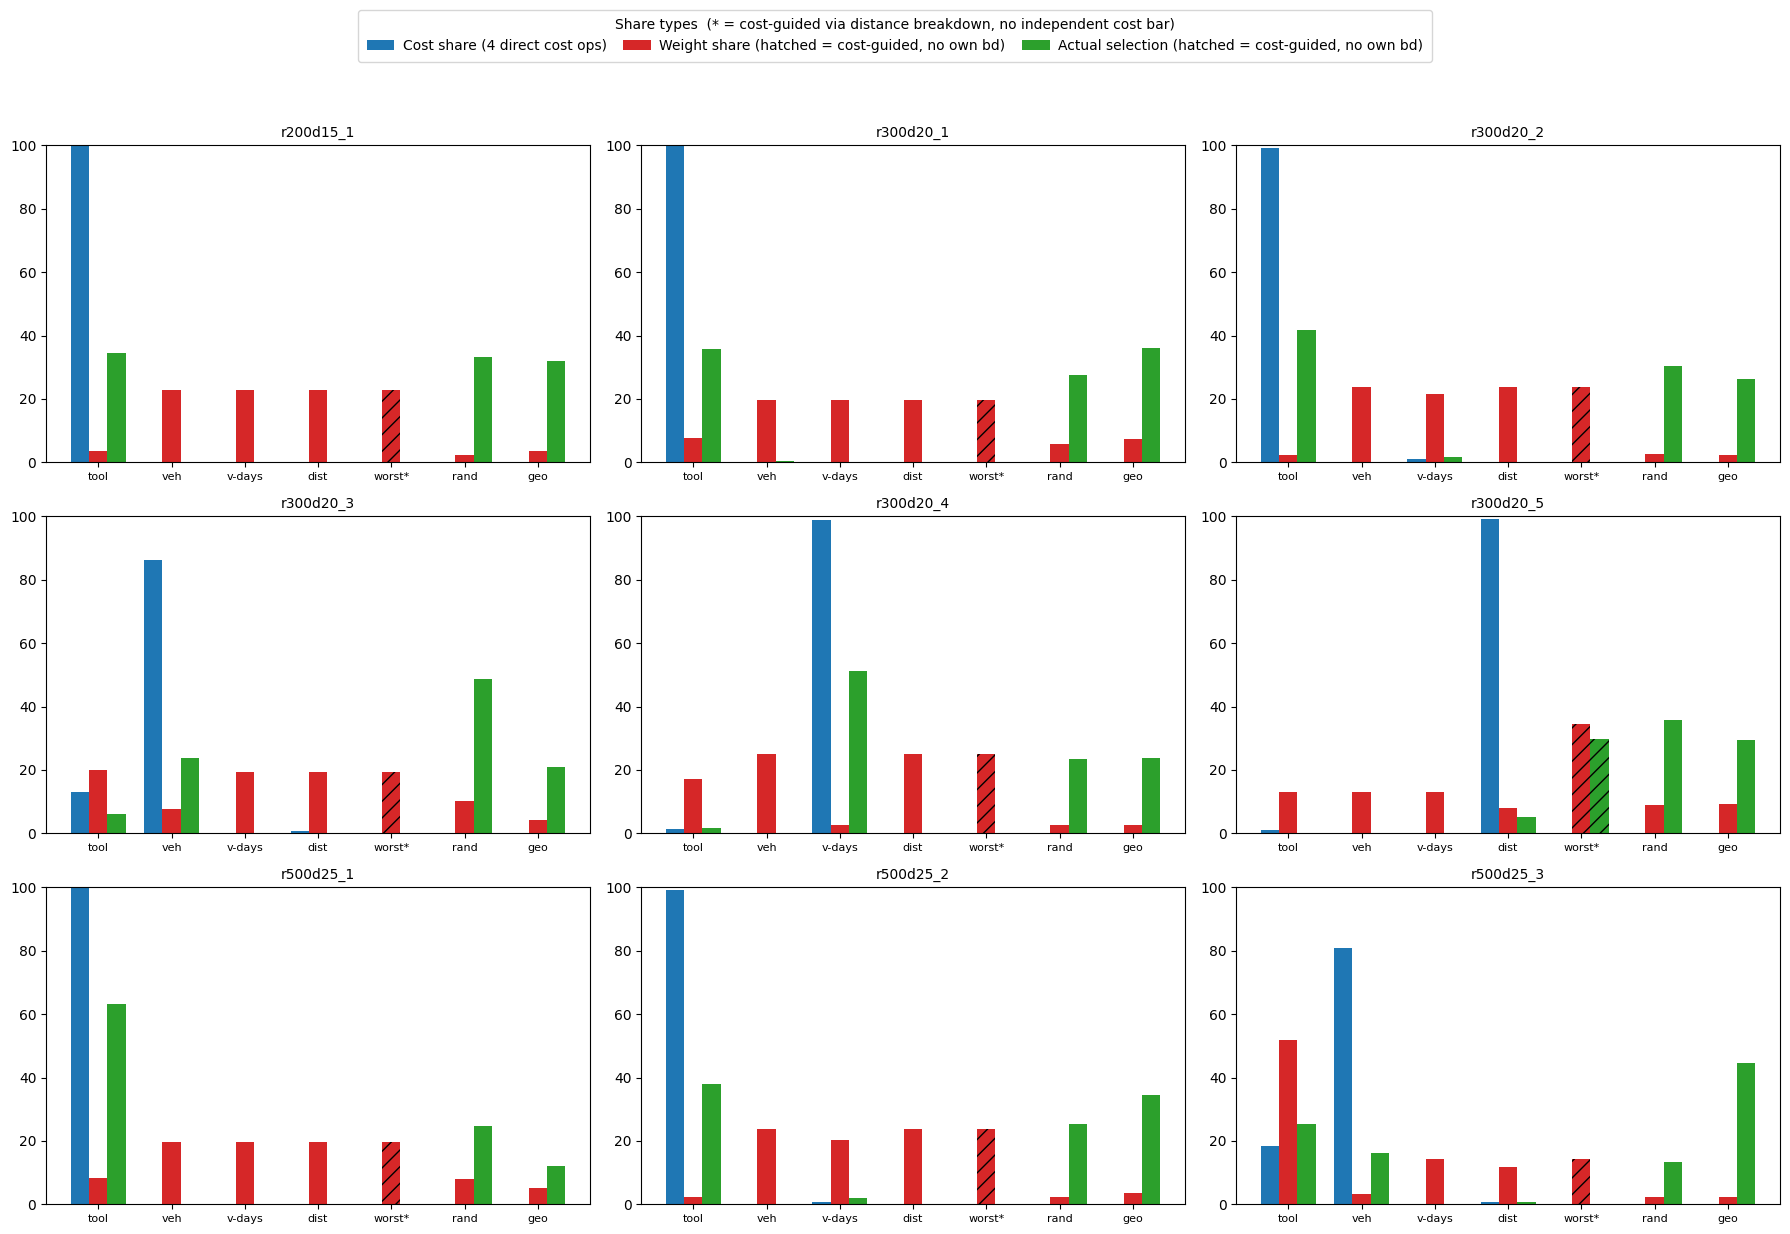

In [ ]:
all_ops = ['tool', 'vehicle', 'vehicle_days', 'distance', 'worst_day', 'random', 'geo']
wb_cols = ['wb_tool', 'wb_vehicle', 'wb_veh_days', 'wb_distance', 'wb_worst', 'wb_random', 'wb_geo']
bd_cols = ['bd_tool', 'bd_vehicle', 'bd_veh_days', 'bd_distance']

COST_GUIDED_NO_OWN_BD = {'worst_day'}   # cost-guided but no independent breakdown column

names = sorted(dfs.keys())
cols = 3
rows = -(-len(names) // cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
axes = axes.flatten()

for i, name in enumerate(names):
    ax = axes[i]
    df = dfs[name]
    final = df.iloc[-1]


    bd = [final[c] for c in bd_cols]
    bd_pct = [b / sum(bd) * 100 for b in bd]  # sums to 100%

 
    wb = [final[c] for c in wb_cols]
    wb_pct = [w / sum(wb) * 100 for w in wb]


    counts = df['break_op'].value_counts()
    total = counts.sum()
    sel_pct = [counts.get(op, 0) / total * 100 for op in all_ops]

    x = list(range(len(all_ops)))
    w = 0.25

   
    ax.bar([j - w for j in x[:4]], bd_pct, w,
           label='Cost share (4 direct cost ops)', color='tab:blue')

   
    for j, op in enumerate(all_ops):
        hatch = '//' if op in COST_GUIDED_NO_OWN_BD else ''
        ax.bar(j, wb_pct[j], w, color='tab:red', hatch=hatch,
               label='Weight share (hatched = cost-guided, no own bd)' if (j == 0 or (op in COST_GUIDED_NO_OWN_BD and j == all_ops.index(op))) else '_nolegend_')

   
    for j, op in enumerate(all_ops):
        hatch = '//' if op in COST_GUIDED_NO_OWN_BD else ''
        ax.bar(j + w, sel_pct[j], w, color='tab:green', hatch=hatch,
               label='Actual selection (hatched = cost-guided, no own bd)' if (j == 0 or (op in COST_GUIDED_NO_OWN_BD and j == all_ops.index(op))) else '_nolegend_')

    ax.set_xticks(x)
    ax.set_xticklabels(['tool', 'veh', 'v-days', 'dist', 'worst*', 'rand', 'geo'], fontsize=8)
    ax.set_title(name.replace('challenge_', ''), fontsize=10)
    ax.set_ylim(0, 100)

for i in range(len(names), len(axes)):
    axes[i].set_visible(False)

# Deduplicate legend entries
seen = set()
handles_dedup, labels_dedup = [], []
for ax in axes[:len(names)]:
    for h, l in zip(*ax.get_legend_handles_labels()):
        if l not in seen and l != '_nolegend_':
            seen.add(l)
            handles_dedup.append(h)
            labels_dedup.append(l)

fig.legend(
    handles_dedup, labels_dedup,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.03),
    ncol=3,
    fontsize=10,
    frameon=True,
    borderpad=0.6,
    columnspacing=1.2,
    handlelength=2.0,
    handletextpad=0.6,
    fancybox=True,
    shadow=False,
    title='Share types  (* = cost-guided via distance breakdown, no independent cost bar)',
    title_fontsize=10,
 )

fig.savefig('operator_cost_weight_selection_shares.png', dpi=300, bbox_inches='tight')
plt.tight_layout(rect=[0, 0, 1, 0.94])

In [81]:
from scipy.stats import pearsonr

cost_shares = []
selection_shares = []

cost_ops = ['tool', 'vehicle', 'vehicle_days', 'distance']

for name, df in dfs.items():
    breakdown = [df['bd_tool'].mean(), df['bd_vehicle'].mean(), 
                 df['bd_veh_days'].mean(), df['bd_distance'].mean()]
    breakdown_pct = [b / sum(breakdown) for b in breakdown]
    
    cost_df = df[df['break_op'].isin(cost_ops)]
    counts = cost_df['break_op'].value_counts()
    total = counts.sum()
    sel = [counts.get(comp, 0) / total for comp in cost_ops]
    
    cost_shares.extend(breakdown_pct)
    selection_shares.extend(sel)

r, p = pearsonr(cost_shares, selection_shares)
print(f'Pearson r = {r:.3f}, p = {p:.6f}')

Pearson r = 0.966, p = 0.000000


In [82]:
from scipy.stats import pearsonr
import numpy as np

all_bd = []
all_wb = []
all_sel = []

# Keep this comparison strictly on cost-targeted operators
cost_ops = ['tool', 'vehicle', 'vehicle_days', 'distance']
wb_cost_cols = ['wb_tool', 'wb_vehicle', 'wb_veh_days', 'wb_distance']

for name, df in dfs.items():
    final = df.iloc[-1]

    bd = [final[c] for c in bd_cols]
    bd_pct = [b / sum(bd) for b in bd]

    wb = [final[c] for c in wb_cost_cols]
    wb_pct = [w / sum(wb) for w in wb]

    cost_df = df[df['break_op'].isin(cost_ops)]
    counts = cost_df['break_op'].value_counts()
    total = counts.sum()
    sel = [counts.get(comp, 0) / total for comp in cost_ops]

    all_bd.extend(bd_pct)
    all_wb.extend(wb_pct)
    all_sel.extend(sel)

r_vanilla, _ = pearsonr(all_bd, all_wb)
r_ours, _ = pearsonr(all_bd, all_sel)

mae_vanilla = np.mean(np.abs(np.array(all_bd) - np.array(all_wb)))
mae_ours = np.mean(np.abs(np.array(all_bd) - np.array(all_sel)))

print(f'Correlation with cost share:')
print(f'  Vanilla (weight only):  r = {r_vanilla:.3f}')
print(f'  Ours (weight × cost):   r = {r_ours:.3f}')
print(f'')
print(f'Mean absolute error from cost share:')
print(f'  Vanilla (weight only):  MAE = {mae_vanilla:.3f}')
print(f'  Ours (weight × cost):   MAE = {mae_ours:.3f}')

Correlation with cost share:
  Vanilla (weight only):  r = -0.765
  Ours (weight × cost):   r = 0.969

Mean absolute error from cost share:
  Vanilla (weight only):  MAE = 0.440
  Ours (weight × cost):   MAE = 0.035


## Complexity (Big-O + model size)

This cell set gives complexity for the implemented algorithm and model-size counts for the exact CP-SAT fallback model.

- Routing is solved with OR-Tools Routing (CP-based search), not a classical MIP like Gurobi.
- Feasibility repair uses CP-SAT and has explicit integer variables/constraints we can count.
- Runtime section below uses existing files in `logs/` only (no re-run), so it is fast.

In [83]:
import re
import json
from pathlib import Path
import pandas as pd

instance_files = sorted(Path('instances').glob('challenge_*.txt'))

rows = []
for p in instance_files:
    m = re.search(r'r(\d+)d(\d+)', p.stem)
    if not m:
        continue
    n = int(m.group(1))
    d = int(m.group(2))
    s = 2 * n  # delivery + pickup stops
    avg_s_day = s / d if d else float('nan')

    # Data-prep cost in routing/solver.py builds dense distance matrices per day: O(s_day^2).
    # Across all days this is O(sum_d s_d^2), worst-case O((2n)^2), balanced O(4n^2/d).
    rows.append({
        'instance': p.stem,
        'n_requests (n)': n,
        'days (d)': d,
        'stops (2n)': s,
        'avg_stops/day': round(avg_s_day, 2),
        'prep_matrix_cost_balanced': f'O(4*n^2/d) ~ O({round(4*n*n/d) if d else "nan"})',
        'prep_matrix_cost_worst': f'O(n^2) ~ O({(2*n)*(2*n)})',
    })

complexity_df = pd.DataFrame(rows).sort_values('instance').reset_index(drop=True)
display(complexity_df)

print('--- Complexity summary used in report ---')
print('1) ALNS outer loop with I iterations:')
print('   O(I * (destroy + repair + reroute(changed_days)))')
print('   Dominant controlled term is rerouting prep O(sum_d s_d^2), upper-bounded by O(n^2) per iteration.')
print('   So practical upper expression: O(I * n^2) + solver-search cost (problem dependent).')
print('')
print('2) CP-SAT feasibility repair model size for one tool type with n_t requests:')
print('   - Integer vars: 2*n_t  (start and end per request)')
print('   - Interval vars: n_t')
print('   - Explicit linear constraints: n_t (horizon bounds) + 1 cumulative resource constraint')
print('   - Hints: up to n_t (do not change feasibility region)')
print('')
print('3) OR-Tools routing model: CP routing search (not MIP in this code), so no fixed MILP var/constraint count is exposed.')

,instance,n_requests (n),days (d),stops (2n),avg_stops/day,prep_matrix_cost_balanced,prep_matrix_cost_worst
0,challenge_r100d10_1,100,10,200,20.00,O(4*n^2/d) ~ O(4000),O(n^2) ~ O(40000)
1,challenge_r100d10_2,100,10,200,20.00,O(4*n^2/d) ~ O(4000),O(n^2) ~ O(40000)
2,challenge_r100d10_3,100,10,200,20.00,O(4*n^2/d) ~ O(4000),O(n^2) ~ O(40000)
3,challenge_r100d10_4,100,10,200,20.00,O(4*n^2/d) ~ O(4000),O(n^2) ~ O(40000)
4,challenge_r100d10_5,100,10,200,20.00,O(4*n^2/d) ~ O(4000),O(n^2) ~ O(40000)
5,challenge_r200d15_1,200,15,400,26.67,O(4*n^2/d) ~ O(10667),O(n^2) ~ O(160000)
6,challenge_r200d15_2,200,15,400,26.67,O(4*n^2/d) ~ O(10667),O(n^2) ~ O(160000)
7,challenge_r200d15_3,200,15,400,26.67,O(4*n^2/d) ~ O(10667),O(n^2) ~ O(160000)
8,challenge_r200d15_4,200,15,400,26.67,O(4*n^2/d) ~ O(10667),O(n^2) ~ O(160000)
9,challenge_r300d20_1,300,20,600,30.00,O(4*n^2/d) ~ O(18000),O(n^2) ~ O(360000)


--- Complexity summary used in report ---
1) ALNS outer loop with I iterations:
   O(I * (destroy + repair + reroute(changed_days)))
   Dominant controlled term is rerouting prep O(sum_d s_d^2), upper-bounded by O(n^2) per iteration.
   So practical upper expression: O(I * n^2) + solver-search cost (problem dependent).

2) CP-SAT feasibility repair model size for one tool type with n_t requests:
   - Integer vars: 2*n_t  (start and end per request)
   - Interval vars: n_t
   - Explicit linear constraints: n_t (horizon bounds) + 1 cumulative resource constraint
   - Hints: up to n_t (do not change feasibility region)

3) OR-Tools routing model: CP routing search (not MIP in this code), so no fixed MILP var/constraint count is exposed.


In [84]:
from pathlib import Path
import re
import json
import time
import subprocess
import sys
from datetime import datetime
import pandas as pd

log_dir = Path('logs')
csv_logs = sorted(log_dir.glob('challenge_*_iterations.csv'))
bench_file = log_dir / 'runtime_benchmarks.jsonl'

def run_and_record_benchmarks(
    instances,
    method='alns',
    repeats=1,
    timeout_sec=None,
    run_label='manual',
    keep_existing=True,
    dry_run=True,
):
    
    existing = []
    if bench_file.exists():
        # Handle UTF-8 files with optional BOM.
        with open(bench_file, 'r', encoding='utf-8-sig') as fh:
            for line in fh:
                line = line.strip()
                if line:
                    existing.append(json.loads(line))

    existing_keys = {(e['instance'], e.get('method', 'alns')) for e in existing}
    to_run = []
    for inst in instances:
        key = (inst, method)
        if keep_existing and key in existing_keys:
            continue
        to_run.append(inst)

    print(f'Planned runs: {len(to_run)} (dry_run={dry_run})')
    if dry_run:
        return pd.DataFrame(existing) if existing else pd.DataFrame()

    records = []
    for inst in to_run:
        instance_file = Path('instances') / f'{inst}.txt'
        if not instance_file.exists():
            print(f'SKIP missing instance file: {instance_file}')
            continue

        for rep in range(repeats):
            cmd = [sys.executable, 'main.py', str(instance_file), '--method', method]
            t0 = time.perf_counter()
            rc = -999
            timed_out = False
            try:
                out = subprocess.run(
                    cmd,
                    capture_output=True,
                    text=True,
                    timeout=timeout_sec,
                    check=False,
)
                rc = out.returncode
                tail = '\n'.join(out.stdout.splitlines()[-5:]) if out.stdout else ''
            except subprocess.TimeoutExpired as ex:
                timed_out = True
                rc = -1
                tail = f'TIMEOUT: {ex}'

            dt = time.perf_counter() - t0
            rec = {
                'timestamp_utc': datetime.utcnow().isoformat(timespec='seconds') + 'Z',
                'instance': inst,
                'method': method,
                'repeat': rep + 1,
                'wall_time_sec': dt,
                'returncode': rc,
                'timed_out': timed_out,
                'run_label': run_label,
                'stdout_tail': tail,
            }
            records.append(rec)
            print(f"{inst} rep {rep + 1}/{repeats}: {dt:.2f}s rc={rc} timeout={timed_out}")

    if records:
        with open(bench_file, 'a', encoding='utf-8') as fh:
            for rec in records:
                fh.write(json.dumps(rec) + '\n')
    
    all_records = existing + records
    return pd.DataFrame(all_records) if all_records else pd.DataFrame()

def load_exact_runtime_records():
    if not bench_file.exists():
        return pd.DataFrame()
    rows = []
    # Handle UTF-8 files with optional BOM.
    with open(bench_file, 'r', encoding='utf-8-sig') as fh:
        for line in fh:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)

# --- Mode A: exact runtime records (preferred) ---
exact_df = load_exact_runtime_records()

if not exact_df.empty:
    m = exact_df['instance'].str.extract(r'r(\d+)d(\d+)')
    exact_df['family'] = 'r' + m[0].fillna('unknown') + 'd' + m[1].fillna('unknown')

    # Keep successful, non-timeout runs for stats
    exact_ok = exact_df[(exact_df['returncode'] == 0) & (~exact_df['timed_out'])].copy()

    print('--- Exact runtime records found (from runtime_benchmarks.jsonl) ---')
    display(exact_ok[['timestamp_utc', 'instance', 'family', 'method', 'repeat', 'wall_time_sec', 'run_label']])

    if not exact_ok.empty:
        print('\n--- Exact runtime stats by instance ---')
        by_instance = exact_ok.groupby('instance')['wall_time_sec'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).sort_index()
        display(by_instance)

        print('\n--- Exact runtime stats by challenge family ---')
        by_family_exact = exact_ok.groupby('family')['wall_time_sec'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).sort_index()
        display(by_family_exact)
    else:
        print('No successful exact runs yet. Use run_and_record_benchmarks(..., dry_run=False).')

else:
    print('No exact runtime benchmark file yet (logs/runtime_benchmarks.jsonl).')

    # --- Mode B: fallback estimate from file timestamps ---
    runtime_rows = []
    for csv_path in csv_logs:
        instance = csv_path.name.replace('_iterations.csv', '')
        m = re.search(r'r(\d+)d(\d+)', instance)
        family = f"r{m.group(1)}d{m.group(2)}" if m else 'unknown'

        st = csv_path.stat()
        runtime_sec_est = max(0.0, st.st_mtime - st.st_ctime)

        summary_path = log_dir / f'{instance}_summary.json'
        iterations = None
        best_cost = None
        stop_reason = None
        if summary_path.exists():
            with open(summary_path, 'r', encoding='utf-8') as fh:
                s = json.load(fh)
            iterations = s.get('iterations_run')
            best_cost = s.get('final_best_cost')
            stop_reason = s.get('stop_reason')

        iter_per_sec_est = None
        if iterations and runtime_sec_est > 0:
            iter_per_sec_est = iterations / runtime_sec_est

        runtime_confidence = 'high' if runtime_sec_est >= 5 else 'low'

        runtime_rows.append({
            'instance': instance,
            'family': family,
            'iterations': iterations,
            'runtime_sec_est': runtime_sec_est,
            'runtime_min_est': runtime_sec_est / 60.0,
            'iter_per_sec_est': iter_per_sec_est,
            'final_best_cost': best_cost,
            'stop_reason': stop_reason,
            'runtime_confidence': runtime_confidence,
            'runtime_source': 'timestamps(iterations.csv)',
        })

    runtime_df = pd.DataFrame(runtime_rows).sort_values('instance').reset_index(drop=True)
    display(runtime_df)

    print('--- Overall runtime statistics (estimated) ---')
    if not runtime_df.empty:
        overall = runtime_df['runtime_sec_est'].describe(percentiles=[0.25, 0.5, 0.75])
        print(overall.to_string())

        print('\n--- Runtime by challenge family (estimated) ---')
        by_family_all = runtime_df.groupby('family')['runtime_sec_est'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
        display(by_family_all)

        print('\n--- Iteration speed statistics (estimated) ---')
        ips = runtime_df['iter_per_sec_est'].dropna()
        if len(ips) > 0:
            print(ips.describe(percentiles=[0.25, 0.5, 0.75]).to_string())
        else:
            print('No iteration-speed estimate available.')
    else:
        print('No challenge iteration logs found in logs/.')

print('\nHow to collect better runtimes now:')
print("1) dry-run plan: run_and_record_benchmarks(['challenge_r200d15_1','challenge_r300d20_4'], dry_run=True)")
print("2) run exact timing and persist: run_and_record_benchmarks(['challenge_r200d15_1','challenge_r300d20_4'], repeats=2, dry_run=False)")
print("3) then rerun this cell to get exact statistics from logs/runtime_benchmarks.jsonl")

--- Exact runtime records found (from runtime_benchmarks.jsonl) ---


,timestamp_utc,instance,family,method,repeat,wall_time_sec,run_label
0,2026-05-15T11:48:36Z,challenge_r200d15_1,r200d15,alns,1,286.164696,analysis_notebook
1,2026-05-15T11:55:10Z,challenge_r300d20_1,r300d20,alns,1,393.268649,analysis_notebook
2,2026-05-15T12:01:10Z,challenge_r300d20_2,r300d20,alns,1,360.090675,analysis_notebook
3,2026-05-15T12:06:56Z,challenge_r300d20_3,r300d20,alns,1,345.795848,analysis_notebook
4,2026-05-15T12:12:55Z,challenge_r300d20_4,r300d20,alns,1,359.803098,analysis_notebook
5,2026-05-15T12:18:35Z,challenge_r300d20_5,r300d20,alns,1,340.090303,analysis_notebook
6,2026-05-15T12:26:19Z,challenge_r500d25_1,r500d25,alns,1,463.287025,analysis_notebook
7,2026-05-15T12:35:57Z,challenge_r500d25_2,r500d25,alns,1,577.889621,analysis_notebook
8,2026-05-15T12:45:17Z,challenge_r500d25_3,r500d25,alns,1,560.544252,analysis_notebook



--- Exact runtime stats by instance ---


,count,mean,median,std,min,max
instance,,,,,,
challenge_r200d15_1,1,286.164696,286.164696,NaN,286.164696,286.164696
challenge_r300d20_1,1,393.268649,393.268649,NaN,393.268649,393.268649
challenge_r300d20_2,1,360.090675,360.090675,NaN,360.090675,360.090675
challenge_r300d20_3,1,345.795848,345.795848,NaN,345.795848,345.795848
challenge_r300d20_4,1,359.803098,359.803098,NaN,359.803098,359.803098
challenge_r300d20_5,1,340.090303,340.090303,NaN,340.090303,340.090303
challenge_r500d25_1,1,463.287025,463.287025,NaN,463.287025,463.287025
challenge_r500d25_2,1,577.889621,577.889621,NaN,577.889621,577.889621
challenge_r500d25_3,1,560.544252,560.544252,NaN,560.544252,560.544252



--- Exact runtime stats by challenge family ---


,count,mean,median,std,min,max
family,,,,,,
r200d15,1,286.164696,286.164696,NaN,286.164696,286.164696
r300d20,5,359.809715,359.803098,20.644751,340.090303,393.268649
r500d25,3,533.906966,560.544252,61.770523,463.287025,577.889621



How to collect better runtimes now:
1) dry-run plan: run_and_record_benchmarks(['challenge_r200d15_1','challenge_r300d20_4'], dry_run=True)
2) run exact timing and persist: run_and_record_benchmarks(['challenge_r200d15_1','challenge_r300d20_4'], repeats=2, dry_run=False)
3) then rerun this cell to get exact statistics from logs/runtime_benchmarks.jsonl


## Exact Runtime Collection (optional)

Use this cell to run selected instances with wall-clock timing and persist results to `logs/runtime_benchmarks.jsonl`.

Set `RUN_BENCHMARKS = True` only when you want to execute (can take long).

In [85]:
# Toggle this to run exact timing benchmarks
RUN_BENCHMARKS = True

# Choose the instances you care about (add challenge_r200d15_4 if/when its instance file exists)
TARGET_INSTANCES = [
    'challenge_r200d15_1',
    'challenge_r300d20_1',
    'challenge_r300d20_2',
    'challenge_r300d20_3',
    'challenge_r300d20_4',
    'challenge_r300d20_5',
    'challenge_r500d25_1',
    'challenge_r500d25_2',
    'challenge_r500d25_3',
]

# Suggested settings to keep runs manageable
REPEATS = 1
TIMEOUT_SEC = None      # e.g. 5400 for 90-min cap per run
KEEP_EXISTING = True    # do not rerun instances already recorded
RUN_LABEL = 'analysis_notebook'

print(f'Benchmark plan: {len(TARGET_INSTANCES)} instances, repeats={REPEATS}, run={RUN_BENCHMARKS}')

# Always show the plan first
_ = run_and_record_benchmarks(
    TARGET_INSTANCES,
    repeats=REPEATS,
    timeout_sec=TIMEOUT_SEC,
    keep_existing=KEEP_EXISTING,
    run_label=RUN_LABEL,
    dry_run=True,
)

if RUN_BENCHMARKS:
    exact_records = run_and_record_benchmarks(
        TARGET_INSTANCES,
        repeats=REPEATS,
        timeout_sec=TIMEOUT_SEC,
        keep_existing=KEEP_EXISTING,
        run_label=RUN_LABEL,
        dry_run=False,
    )
    print('\nDone. Re-run the runtime statistics cell above to refresh exact values.')
    if not exact_records.empty:
        display(exact_records.tail(10))
else:
    print('Set RUN_BENCHMARKS = True to execute and persist exact wall-clock runtimes.')

Benchmark plan: 9 instances, repeats=1, run=True
Planned runs: 0 (dry_run=True)
Planned runs: 0 (dry_run=False)

Done. Re-run the runtime statistics cell above to refresh exact values.


,timestamp_utc,instance,method,repeat,wall_time_sec,returncode,timed_out,run_label,stdout_tail
0,2026-05-15T11:48:36Z,challenge_r200d15_1,alns,1,286.164696,0,False,analysis_notebook,FINAL COST\n================================...
1,2026-05-15T11:55:10Z,challenge_r300d20_1,alns,1,393.268649,0,False,analysis_notebook,FINAL COST\n================================...
2,2026-05-15T12:01:10Z,challenge_r300d20_2,alns,1,360.090675,0,False,analysis_notebook,FINAL COST\n================================...
3,2026-05-15T12:06:56Z,challenge_r300d20_3,alns,1,345.795848,0,False,analysis_notebook,FINAL COST\n================================...
4,2026-05-15T12:12:55Z,challenge_r300d20_4,alns,1,359.803098,0,False,analysis_notebook,FINAL COST\n================================...
5,2026-05-15T12:18:35Z,challenge_r300d20_5,alns,1,340.090303,0,False,analysis_notebook,FINAL COST\n================================...
6,2026-05-15T12:26:19Z,challenge_r500d25_1,alns,1,463.287025,0,False,analysis_notebook,FINAL COST\n================================...
7,2026-05-15T12:35:57Z,challenge_r500d25_2,alns,1,577.889621,0,False,analysis_notebook,FINAL COST\n================================...
8,2026-05-15T12:45:17Z,challenge_r500d25_3,alns,1,560.544252,0,False,analysis_notebook,FINAL COST\n================================...


## Method comparison: heuristics vs ALNS

> This section compares final objective values and runtime across methods:
>
> - `alns` (cost-guided operator selection)
> - greedy baselines (`greedy_gls` and `greedy_*_gls`)
>
> It uses persisted solution files in `solutions/<method>/...` and exact benchmark records in `logs/runtime_benchmarks.jsonl` when available.

In [86]:
from pathlib import Path
from main import METHODS

# Optional: run exact wall-clock benchmarks for multiple methods
RUN_METHOD_COMPARISON_BENCHMARKS = False

COMPARE_METHODS = [
    'alns',
    'greedy_gls',
    'greedy_edd_gls',
    'greedy_tight_gls',
    'greedy_heavy_gls',
    'greedy_late_gls',
]
COMPARE_METHODS = [m for m in COMPARE_METHODS if m in METHODS]

COMPARE_INSTANCES = [
    'challenge_r200d15_1',
    'challenge_r300d20_1',
    'challenge_r300d20_2',
    'challenge_r300d20_3',
    'challenge_r300d20_4',
    'challenge_r300d20_5',
    'challenge_r500d25_1',
    'challenge_r500d25_2',
    'challenge_r500d25_3',
]

CMP_REPEATS = 1
CMP_TIMEOUT_SEC = None
CMP_KEEP_EXISTING = True
CMP_RUN_LABEL = 'method_comparison'

print(f'Method benchmark plan: {len(COMPARE_METHODS)} methods x {len(COMPARE_INSTANCES)} instances')
for m in COMPARE_METHODS:
    print(f'  - {m}')
    _ = run_and_record_benchmarks(
        COMPARE_INSTANCES,
        method=m,
        repeats=CMP_REPEATS,
        timeout_sec=CMP_TIMEOUT_SEC,
        keep_existing=CMP_KEEP_EXISTING,
        run_label=CMP_RUN_LABEL,
        dry_run=True,
    )

if RUN_METHOD_COMPARISON_BENCHMARKS:
    for m in COMPARE_METHODS:
        print(f'\nRunning exact benchmarks for method: {m}')
        _ = run_and_record_benchmarks(
            COMPARE_INSTANCES,
            method=m,
            repeats=CMP_REPEATS,
            timeout_sec=CMP_TIMEOUT_SEC,
            keep_existing=CMP_KEEP_EXISTING,
            run_label=CMP_RUN_LABEL,
            dry_run=False,
        )
    print('\nDone. Re-run the next cell to refresh method comparison tables/plots.')
else:
    print('Set RUN_METHOD_COMPARISON_BENCHMARKS = True to execute full multi-method benchmarking.')

Method benchmark plan: 6 methods x 9 instances
  - alns
Planned runs: 0 (dry_run=True)
  - greedy_gls
Planned runs: 9 (dry_run=True)
  - greedy_edd_gls
Planned runs: 9 (dry_run=True)
  - greedy_tight_gls
Planned runs: 9 (dry_run=True)
  - greedy_heavy_gls
Planned runs: 9 (dry_run=True)
  - greedy_late_gls
Planned runs: 9 (dry_run=True)
Set RUN_METHOD_COMPARISON_BENCHMARKS = True to execute full multi-method benchmarking.


--- Objective comparison (lower is better) ---


,instance,method,cost,has_solution,best_cost,gap_pct_to_best
0,challenge_r200d15_1,alns,2.772438e+09,True,2.772438e+09,0.000000
9,challenge_r200d15_1,greedy_gls,3.472836e+09,True,2.772438e+09,25.262896
1,challenge_r300d20_1,alns,4.054681e+09,True,4.054681e+09,0.000000
10,challenge_r300d20_1,greedy_gls,4.265181e+09,True,4.054681e+09,5.191539
2,challenge_r300d20_2,alns,3.070630e+09,True,3.070630e+09,0.000000
11,challenge_r300d20_2,greedy_gls,3.271034e+09,True,3.070630e+09,6.526495
3,challenge_r300d20_3,alns,2.095184e+08,True,2.095184e+08,0.000000
12,challenge_r300d20_3,greedy_gls,2.407469e+08,True,2.095184e+08,14.904867
4,challenge_r300d20_4,alns,2.793339e+09,True,2.793339e+09,0.000000
13,challenge_r300d20_4,greedy_gls,3.244499e+09,True,2.793339e+09,16.151269



--- Quality summary by method ---


,solved_instances,mean_cost,median_cost,mean_gap_pct,median_gap_pct
method,,,,,
alns,9,2.941944e+10,2.793339e+09,0.000000,0.000000
greedy_gls,9,3.370572e+10,3.271034e+09,13.731801,14.886375



--- Runtime summary by method (exact wall-clock) ---


,count,mean,median,std,min,max
method,,,,,,
alns,9,409.659352,360.090675,102.056534,286.164696,577.889621



--- Combined quality + runtime view ---


,instance,method,cost,has_solution,best_cost,gap_pct_to_best,wall_time_sec
0,challenge_r200d15_1,alns,2.772438e+09,True,2.772438e+09,0.000000,286.164696
9,challenge_r200d15_1,greedy_gls,3.472836e+09,True,2.772438e+09,25.262896,NaN
1,challenge_r300d20_1,alns,4.054681e+09,True,4.054681e+09,0.000000,393.268649
10,challenge_r300d20_1,greedy_gls,4.265181e+09,True,4.054681e+09,5.191539,NaN
2,challenge_r300d20_2,alns,3.070630e+09,True,3.070630e+09,0.000000,360.090675
11,challenge_r300d20_2,greedy_gls,3.271034e+09,True,3.070630e+09,6.526495,NaN
3,challenge_r300d20_3,alns,2.095184e+08,True,2.095184e+08,0.000000,345.795848
12,challenge_r300d20_3,greedy_gls,2.407469e+08,True,2.095184e+08,14.904867,NaN
4,challenge_r300d20_4,alns,2.793339e+09,True,2.793339e+09,0.000000,359.803098
13,challenge_r300d20_4,greedy_gls,3.244499e+09,True,2.793339e+09,16.151269,NaN


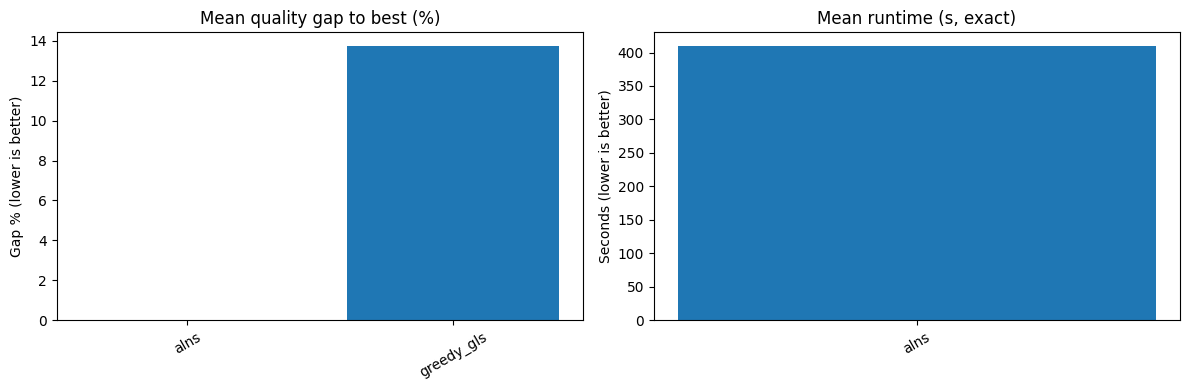

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

def read_solution_cost(solution_path: Path):
    if not solution_path.exists():
        return None
    try:
        with open(solution_path, 'r', encoding='utf-8') as fh:
            for line in fh:
                if line.startswith('COST ='):
                    return int(line.split('=', 1)[1].strip())
    except Exception:
        return None
    return None

def collect_solution_scores(instances, methods):
    rows = []
    for method in methods:
        for inst in instances:
            sol_path = Path('solutions') / method / f'{inst}_solution.txt'
            cost = read_solution_cost(sol_path)
            rows.append({
                'instance': inst,
                'method': method,
                'cost': cost,
                'has_solution': cost is not None,
            })
    return pd.DataFrame(rows)

def load_benchmark_df(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    rows = []
    with open(path, 'r', encoding='utf-8-sig') as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                # Skip malformed lines instead of failing the full analysis cell.
                continue
    return pd.DataFrame(rows)

score_df = collect_solution_scores(COMPARE_INSTANCES, COMPARE_METHODS)

if score_df['has_solution'].any():
    valid = score_df[score_df['has_solution']].copy()
    best_per_instance = valid.groupby('instance')['cost'].min().rename('best_cost')
    valid = valid.merge(best_per_instance, on='instance', how='left')
    valid['gap_pct_to_best'] = 100.0 * (valid['cost'] - valid['best_cost']) / valid['best_cost']

    print('--- Objective comparison (lower is better) ---')
    display(valid.sort_values(['instance', 'cost']))

    summary_quality = valid.groupby('method').agg(
        solved_instances=('instance', 'nunique'),
        mean_cost=('cost', 'mean'),
        median_cost=('cost', 'median'),
        mean_gap_pct=('gap_pct_to_best', 'mean'),
        median_gap_pct=('gap_pct_to_best', 'median'),
    ).sort_values('mean_gap_pct')
    print('\n--- Quality summary by method ---')
    display(summary_quality)

    # Runtime comparison from exact benchmark records (if present)
    bench_file = Path('logs') / 'runtime_benchmarks.jsonl'
    exact = load_benchmark_df(bench_file)
    if not exact.empty:
        exact_ok = exact[(exact['returncode'] == 0) & (~exact['timed_out'])].copy()
        exact_ok = exact_ok[exact_ok['instance'].isin(COMPARE_INSTANCES) & exact_ok['method'].isin(COMPARE_METHODS)]
        if not exact_ok.empty:
            rt = exact_ok.groupby(['instance', 'method'])['wall_time_sec'].mean().reset_index()
            rt_summary = exact_ok.groupby('method')['wall_time_sec'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).sort_values('mean')
            print('\n--- Runtime summary by method (exact wall-clock) ---')
            display(rt_summary)

            merged = valid.merge(rt, on=['instance', 'method'], how='left')
            print('\n--- Combined quality + runtime view ---')
            display(merged.sort_values(['instance', 'gap_pct_to_best', 'wall_time_sec']))
        else:
            print('\nNo exact runtime records for selected methods/instances yet.')
    else:
        print('\nNo runtime benchmark file found yet (logs/runtime_benchmarks.jsonl).')

    # Plot: mean quality gap and mean runtime by method
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    qplot = summary_quality.reset_index()
    axes[0].bar(qplot['method'], qplot['mean_gap_pct'])
    axes[0].set_title('Mean quality gap to best (%)')
    axes[0].set_ylabel('Gap % (lower is better)')
    axes[0].tick_params(axis='x', rotation=30)

    exact = load_benchmark_df(Path('logs') / 'runtime_benchmarks.jsonl')
    if not exact.empty:
        exact_ok = exact[(exact['returncode'] == 0) & (~exact['timed_out'])].copy()
        exact_ok = exact_ok[exact_ok['instance'].isin(COMPARE_INSTANCES) & exact_ok['method'].isin(COMPARE_METHODS)]
        if not exact_ok.empty:
            rplot = exact_ok.groupby('method')['wall_time_sec'].mean().reset_index()
            axes[1].bar(rplot['method'], rplot['wall_time_sec'])
            axes[1].set_title('Mean runtime (s, exact)')
            axes[1].set_ylabel('Seconds (lower is better)')
            axes[1].tick_params(axis='x', rotation=30)
        else:
            axes[1].text(0.5, 0.5, 'No exact runtime records yet', ha='center', va='center')
            axes[1].set_axis_off()
    else:
        axes[1].text(0.5, 0.5, 'No exact runtime file yet', ha='center', va='center')
        axes[1].set_axis_off()

    fig.savefig('method_comparison_quality_runtime.png', dpi=300, bbox_inches='tight')
    plt.tight_layout()
else:
    print('No solution files found yet for selected methods/instances. Run methods first, then re-run this cell.')